# UEBA Benchmark - Kiểm định chất lượng dữ liệu trong một ngày

Notebook này kiểm định hai luồng Windows logon độc lập và trình bày các thống kê hỗ trợ điều tra. Các biểu đồ là công cụ mô tả; chúng **không tự tạo nhãn tấn công** nếu chưa có baseline hoặc ground truth.

1. **PHẦN A — Event 4624:** Kiểm tra schema, missingness, duplicate và nhịp lặp nhanh giữa các logon liên tiếp.
2. **PHẦN B — Event 4625:** Phân tích failed logon theo giờ, lý do thất bại và các chuỗi lặp nhanh cần điều tra thêm.
3. **PHẦN C — Dashboard và khuyến nghị:** Tổng hợp các chỉ số đã định nghĩa rõ, tránh suy diễn trực tiếp từ tương quan sang tấn công.

## 1. Khởi tạo Cấu hình & Môi trường

In [38]:
from pathlib import Path
import yaml
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

# ==============================================================================
# THAM SỐ NGÀY KIỂM ĐỊNH (Thay đổi sang bất kỳ ngày nào: day-01, day-02, day-15...)
# ==============================================================================
TARGET_DAY = "day-15"
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
CONFIG_PATH = PROJECT_ROOT / "configs" / "system_config.yaml"

# Nạp cấu hình hệ thống
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy cấu hình: {CONFIG_PATH}")
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f) or {}

off_hours_start = config.get("features", {}).get("off_hours_start", 18)
off_hours_end = config.get("features", {}).get("off_hours_end", 7)

print(f"[*] Đang kiểm định ngày: {TARGET_DAY}")
print(f"[*] Khung giờ ngoài hành chính (Off-hours): Từ {off_hours_start}:00 đến {off_hours_end}:00 sáng")

[*] Đang kiểm định ngày: day-15
[*] Khung giờ ngoài hành chính (Off-hours): Từ 18:00 đến 7:00 sáng


## 2. Nạp dữ liệu Parquet Độc lập bằng Polars

In [39]:
f4624 = INTERIM_DIR / "event_4624" / f"event_4624_{TARGET_DAY}.parquet"
f4625 = INTERIM_DIR / "event_4625" / f"event_4625_{TARGET_DAY}.parquet"

for parquet_path in (f4624, f4625):
    if not parquet_path.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {parquet_path}")

print(f"Đang đọc dữ liệu Parquet cho {TARGET_DAY}...")
df_4624 = pl.read_parquet(f4624)
df_4625 = pl.read_parquet(f4625)

n_4624 = df_4624.height
n_4625 = df_4625.height
total_events = n_4624 + n_4625
if total_events == 0:
    raise ValueError(f"Không có dữ liệu trong hai file của {TARGET_DAY}")

event_ids_4624 = set(df_4624["EventID"].drop_nulls().unique().to_list())
event_ids_4625 = set(df_4625["EventID"].drop_nulls().unique().to_list())
if event_ids_4624 != {4624} or event_ids_4625 != {4625}:
    raise ValueError(f"EventID không khớp: 4624={event_ids_4624}, 4625={event_ids_4625}")

fail_rate = (n_4625 / total_events) * 100

print(f"-> [EVENT 4624] Đăng nhập thành công: {n_4624:,} dòng ({n_4624/total_events*100:.2f}% tổng volume)")
print(f"-> [EVENT 4625] Đăng nhập thất bại:   {n_4625:,} dòng ({fail_rate:.2f}% tổng volume)")

Đang đọc dữ liệu Parquet cho day-15...
-> [EVENT 4624] Đăng nhập thành công: 11,043,849 dòng (97.75% tổng volume)
-> [EVENT 4625] Đăng nhập thất bại:   254,346 dòng (2.25% tổng volume)


---
# PHẦN A: QUALITY CHECK CHUYÊN BIỆT — EVENT 4624 (SUCCESS TELEMETRY)

Mục tiêu: Kiểm tra tính toàn vẹn của successful-logon telemetry và mô tả nhịp thời gian, fan-out host cùng cơ chế xác thực.

### A.1. Kiểm định Missing Values (3 Tầng Phân loại cho 4624)

In [40]:
core_fields = {"Time", "EventID", "UserName", "LogHost", "LogonType"}
omitted_fields = {"Status", "ServiceName", "Destination", "ParentProcessName", "ParentProcessID"}

audit_4624 = []
for col in df_4624.columns:
    null_cnt = df_4624[col].null_count()
    null_pct = (null_cnt / n_4624) * 100
    
    if col in core_fields:
        category = "1. Cốt lõi (Bắt buộc)"
        status = "✅ PASS (0.0%)" if null_cnt == 0 else "❌ FAIL (Có Null)"
    elif col == "FailureReason":
        category = "2. Ngữ cảnh nghiệp vụ"
        status = "✅ Chuẩn (100% Null ở 4624)" if null_pct == 100.0 else "❌ FAIL (Có FailureReason lạ)"
    elif col in omitted_fields:
        category = "3. Lược bỏ theo bộ LANL"
        status = "✅ Chuẩn (100% Omitted)" if null_pct == 100.0 else "⚠️ Khác thường"
    else:
        category = "2. Ngữ cảnh nghiệp vụ"
        status = "ℹ️ Theo dõi theo ngữ cảnh (không có ngưỡng tự động)"
        
    audit_4624.append({
        "Tên trường": col,
        "Phân loại": category,
        "Số lượng Null": null_cnt,
        "Tỷ lệ Null (%)": round(null_pct, 2),
        "Đánh giá": status
    })

df_audit_4624 = pl.DataFrame(audit_4624).sort("Phân loại")
display(df_audit_4624.to_pandas())

# Phụ thuộc ngữ cảnh: Source theo LogonTypeDescription trong 4624
source_4624 = (
    df_4624.group_by("LogonTypeDescription")
    .agg([
        pl.len().alias("Tổng sự kiện"),
        pl.col("Source").null_count().alias("Source Null Count"),
        (pl.col("Source").null_count() / pl.len() * 100).alias("Source Null (%)")
    ])
    .sort("Tổng sự kiện", descending=True)
)
print("\n[*] Tỷ lệ Missing của trường 'Source' theo loại đăng nhập (Event 4624):")
display(source_4624.to_pandas())

,Tên trường,Phân loại,Số lượng Null,Tỷ lệ Null (%),Đánh giá
0,Time,1. Cốt lõi (Bắt buộc),0,0.00,✅ PASS (0.0%)
1,EventID,1. Cốt lõi (Bắt buộc),0,0.00,✅ PASS (0.0%)
2,LogHost,1. Cốt lõi (Bắt buộc),0,0.00,✅ PASS (0.0%)
3,LogonType,1. Cốt lõi (Bắt buộc),0,0.00,✅ PASS (0.0%)
4,UserName,1. Cốt lõi (Bắt buộc),0,0.00,✅ PASS (0.0%)
5,LogonTypeDescription,2. Ngữ cảnh nghiệp vụ,0,0.00,ℹ️ Theo dõi theo ngữ cảnh (không có ngưỡng tự ...
6,DomainName,2. Ngữ cảnh nghiệp vụ,0,0.00,ℹ️ Theo dõi theo ngữ cảnh (không có ngưỡng tự ...
7,LogonID,2. Ngữ cảnh nghiệp vụ,28014,0.25,ℹ️ Theo dõi theo ngữ cảnh (không có ngưỡng tự ...
8,SubjectUserName,2. Ngữ cảnh nghiệp vụ,11030910,99.88,ℹ️ Theo dõi theo ngữ cảnh (không có ngưỡng tự ...
9,SubjectDomainName,2. Ngữ cảnh nghiệp vụ,11030910,99.88,ℹ️ Theo dõi theo ngữ cảnh (không có ngưỡng tự ...



[*] Tỷ lệ Missing của trường 'Source' theo loại đăng nhập (Event 4624):


,LogonTypeDescription,Tổng sự kiện,Source Null Count,Source Null (%)
0,Network,10255523,1593887,15.541743
1,Interactive,504519,1843,0.365298
2,Service,188828,188638,99.899379
3,NetworkClearText,77114,0,0.000000
4,NewCredentials,12939,12939,100.000000
5,Unlock,2289,0,0.000000
6,Batch,1828,0,0.000000
7,RemoteInteractive,379,49,12.928760
8,Local System,326,326,100.000000
9,CachedInteractive,104,0,0.000000


### A.2. Kiểm định trùng lặp & nhịp lặp nhanh

Phân biệt **thành viên thuộc nhóm trùng** với **số dòng dư nếu giữ một bản**. Nhịp lặp nhanh $\le 2s$ chỉ là thống kê mô tả, không mặc định là một session hay một cuộc tấn công.

In [41]:
# 1. Duplicate quan sát được trên toàn bộ 21 cột
exact_members_4624 = int(df_4624.is_duplicated().sum())
unique_rows_4624 = df_4624.n_unique()
exact_excess_4624 = n_4624 - unique_rows_4624
exact_excess_4624_pct = exact_excess_4624 / n_4624 * 100
print(f"[A.2.1] Thành viên thuộc nhóm trùng: {exact_members_4624:,}")
print(f"[A.2.2] Dòng dư nếu giữ một bản: {exact_excess_4624:,} ({exact_excess_4624_pct:.2f}%)")
print("[Lưu ý] Không tự động coi các dòng giống nhau là log thừa nếu chưa đối soát nguồn.")

# 2. Tính nhịp lặp nhanh sau khi gộp các dòng giống hệt nhau
df_4624_dedup = df_4624.unique(maintain_order=False)
rapid_group_keys = ["DomainName", "UserName", "LogHost", "LogonType"]
rapid_4624 = (
    df_4624_dedup.select(["Time", *rapid_group_keys])
    .sort([*rapid_group_keys, "Time"])
    .with_columns([
        pl.col("Time").diff().over(rapid_group_keys).alias("delta_t"),
        pl.col("UserName").str.ends_with("$").alias("is_machine")
    ])
)
rapid_4624_count = int((rapid_4624["delta_t"] <= 2).sum())
rapid_4624_pct = rapid_4624_count / unique_rows_4624 * 100
print(f"[A.2.3] Lần lặp kế tiếp có Delta t <= 2s: {rapid_4624_count:,} ({rapid_4624_pct:.2f}% sau gộp trùng)")

[A.2.1] Thành viên thuộc nhóm trùng: 175,999
[A.2.2] Dòng dư nếu giữ một bản: 133,750 (1.21%)
[Lưu ý] Không tự động coi các dòng giống nhau là log thừa nếu chưa đối soát nguồn.
[A.2.3] Lần lặp kế tiếp có Delta t <= 2s: 8,744,145 (80.15% sau gộp trùng)


### [BIỂU ĐỒ 1] Phổ phân bố Khoảng cách thời gian ($\Delta t$) giữa 2 lần logon liên tiếp

> **Cách đọc:** Biểu đồ mô tả khoảng cách giữa hai event liên tiếp trong cùng identity/domain, host và logon type, sau khi gộp các dòng giống hệt nhau. Đỉnh ở 0–2 giây cho thấy tính lặp nhanh, nhưng chưa đủ để gọi là polling, session hoặc bất thường.

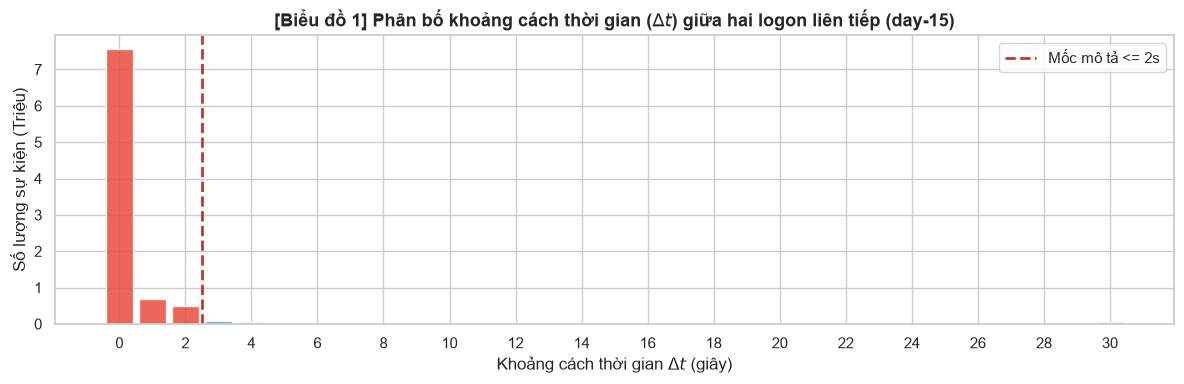

In [42]:
# Tính phân phối delta_t từ 0 đến 30 giây
delta_t_dist = (
    rapid_4624.filter((pl.col("delta_t").is_not_null()) & (pl.col("delta_t") <= 30))
    .group_by("delta_t")
    .agg(pl.len().alias("count"))
    .sort("delta_t")
    .to_pandas()
)

plt.figure(figsize=(12, 4))
colors = ["#e74c3c" if dt <= 2 else "#3498db" for dt in delta_t_dist["delta_t"]]
plt.bar(delta_t_dist["delta_t"], delta_t_dist["count"] / 1e6, color=colors, alpha=0.85)
plt.axvline(2.5, color="#c0392b", linestyle="--", linewidth=2, label="Mốc mô tả <= 2s")
plt.title(rf"[Biểu đồ 1] Phân bố khoảng cách thời gian ($\Delta t$) giữa hai logon liên tiếp ({TARGET_DAY})", fontsize=13, fontweight="bold")
plt.xlabel(r"Khoảng cách thời gian $\Delta t$ (giây)")
plt.ylabel("Số lượng sự kiện (Triệu)")
plt.xticks(range(0, 31, 2))
plt.legend()
plt.tight_layout()
plt.show()

### [BIỂU ĐỒ 2] So sánh tỷ lệ lặp nhanh: tài khoản máy và tài khoản khác

> Hậu tố `$` nhận diện tài khoản máy theo quy ước Active Directory. Nhóm còn lại có thể gồm người dùng, service, scanner hoặc tài khoản hệ thống; vì vậy không gắn nhãn "người dùng thật".

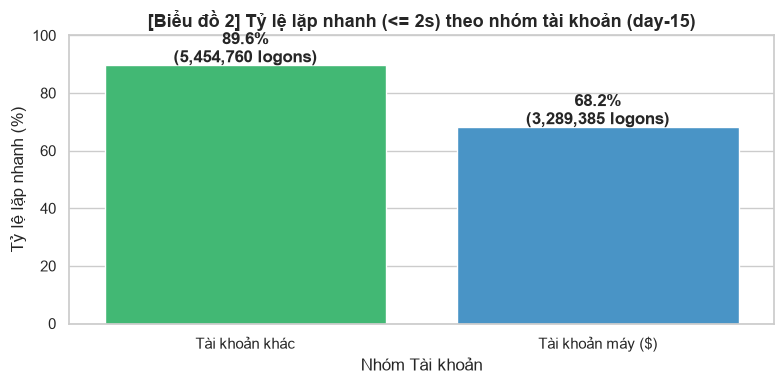

In [43]:
rapid_compare = (
    rapid_4624.group_by("is_machine")
    .agg([
        pl.len().alias("Total_Logons"),
        (pl.col("delta_t") <= 2).sum().alias("Rapid_Logons")
    ])
    .with_columns([
        pl.when(pl.col("is_machine")).then(pl.lit("Tài khoản máy ($)")).otherwise(pl.lit("Tài khoản khác")).alias("Nhóm Tài khoản"),
        (pl.col("Rapid_Logons") / pl.col("Total_Logons") * 100).alias("Rapid_Rate_Pct")
    ])
    .to_pandas()
)

plt.figure(figsize=(8, 4))
sns.barplot(data=rapid_compare, x="Nhóm Tài khoản", y="Rapid_Rate_Pct", hue="Nhóm Tài khoản", palette=["#2ecc71", "#3498db"], legend=False)
plt.title(f"[Biểu đồ 2] Tỷ lệ lặp nhanh (<= 2s) theo nhóm tài khoản ({TARGET_DAY})", fontsize=13, fontweight="bold")
plt.ylabel("Tỷ lệ lặp nhanh (%)")
for idx, row in rapid_compare.iterrows():
    plt.text(idx, row["Rapid_Rate_Pct"] + 1, f"{row['Rapid_Rate_Pct']:.1f}%\n({row['Rapid_Logons']:,} logons)", ha="center", fontweight="bold")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### [BIỂU ĐỒ 3] Phân phối số host trên mỗi identity

> Biểu đồ dùng khóa `DomainName + UserName` để tránh nhập nhầm các tài khoản cùng tên ở hai domain. Các bucket chỉ mô tả fan-out quan sát được; muốn gắn nhãn bất thường phải so với lịch sử của chính identity hoặc baseline nhiều ngày.

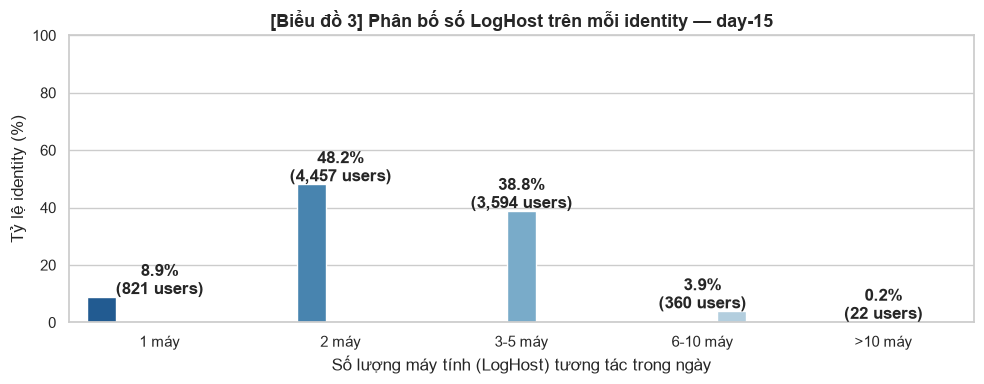

In [44]:
# Đếm số LogHost duy nhất theo identity đầy đủ
user_host_count = (
    df_4624.group_by(["DomainName", "UserName"])
    .agg(pl.col("LogHost").n_unique().alias("distinct_hosts"))
    .with_columns([
        pl.col("UserName").str.ends_with("$").alias("is_machine"),
        pl.when(pl.col("distinct_hosts") == 1).then(pl.lit("1 máy"))
        .when(pl.col("distinct_hosts") == 2).then(pl.lit("2 máy"))
        .when(pl.col("distinct_hosts") <= 5).then(pl.lit("3-5 máy"))
        .when(pl.col("distinct_hosts") <= 10).then(pl.lit("6-10 máy"))
        .otherwise(pl.lit(">10 máy"))
        .alias("Host_Range")
    ])
)

range_order = ["1 máy", "2 máy", "3-5 máy", "6-10 máy", ">10 máy"]
host_fanout = (
    user_host_count.group_by("Host_Range")
    .agg(pl.len().alias("User_Count"))
    .with_columns((pl.col("User_Count") / user_host_count.height * 100).alias("Pct"))
    .to_pandas()
)
host_fanout["Host_Range"] = pd.Categorical(host_fanout["Host_Range"], categories=range_order, ordered=True)
host_fanout = host_fanout.sort_values("Host_Range")

plt.figure(figsize=(10, 4))
sns.barplot(data=host_fanout, x="Host_Range", y="Pct", hue="Host_Range", palette="Blues_r", legend=False)
plt.title(f"[Biểu đồ 3] Phân bố số LogHost trên mỗi identity — {TARGET_DAY}", fontsize=13, fontweight="bold")
plt.xlabel("Số lượng máy tính (LogHost) tương tác trong ngày")
plt.ylabel("Tỷ lệ identity (%)")
for idx, row in host_fanout.reset_index().iterrows():
    plt.text(idx, row["Pct"] + 1, f"{row['Pct']:.1f}%\n({row['User_Count']:,} users)", ha="center", fontweight="bold")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### [BIỂU ĐỒ 4] Phân bố Giao thức Xác thực (`AuthenticationPackage`)

> Thống kê tỷ lệ các gói xác thực để phục vụ baseline. Tên package cho biết cơ chế được ghi nhận, nhưng tự nó không chứng minh lỗ hổng hay một cuộc tấn công.

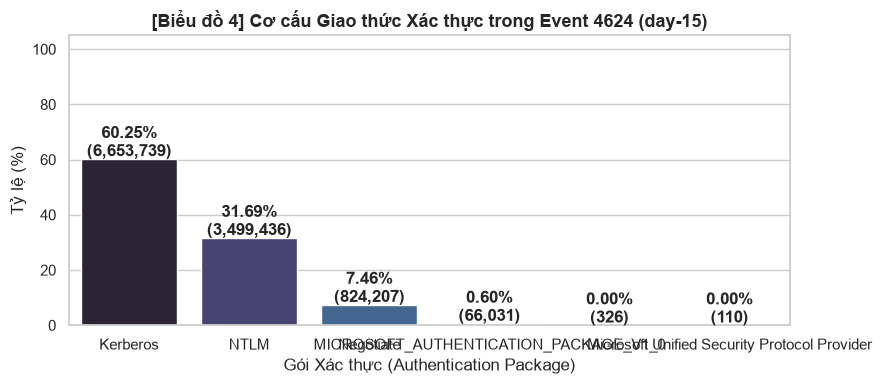

In [45]:
auth_pkg_dist = (
    df_4624.group_by("AuthenticationPackage")
    .agg(pl.len().alias("Count"))
    .with_columns((pl.col("Count") / n_4624 * 100).alias("Pct"))
    .sort("Count", descending=True)
    .to_pandas()
)

plt.figure(figsize=(9, 4))
sns.barplot(data=auth_pkg_dist, x="AuthenticationPackage", y="Pct", hue="AuthenticationPackage", palette="mako", legend=False)
plt.title(f"[Biểu đồ 4] Cơ cấu Giao thức Xác thực trong Event 4624 ({TARGET_DAY})", fontsize=13, fontweight="bold")
plt.xlabel("Gói Xác thực (Authentication Package)")
plt.ylabel("Tỷ lệ (%)")
for idx, row in auth_pkg_dist.iterrows():
    plt.text(idx, row["Pct"] + 1, f"{row['Pct']:.2f}%\n({row['Count']:,})", ha="center", fontweight="bold")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

### A.5. Scorecard Chất lượng riêng cho Event 4624

In [46]:
crit_nulls_4624 = sum(r["Số lượng Null"] for r in audit_4624 if r["Phân loại"] == "1. Cốt lõi (Bắt buộc)")
failure_in_4624 = df_4624["FailureReason"].drop_nulls().len()
day_number = int(TARGET_DAY.split("-")[-1])
expected_start = (day_number - 1) * 86400
expected_end = day_number * 86400
time_min_4624 = df_4624["Time"].min()
time_max_4624 = df_4624["Time"].max()
time_ok_4624 = expected_start <= time_min_4624 and time_max_4624 < expected_end
quality_gate_4624 = crit_nulls_4624 == 0 and failure_in_4624 == 0 and time_ok_4624

scorecard_4624 = [
    {"Tiêu chí Kiểm định 4624": "1. Không có Missing Value ở trường cốt lõi", "Kết quả": f"{crit_nulls_4624} nulls", "Đánh giá": "✅ ĐẠT" if crit_nulls_4624 == 0 else "❌ KHÔNG ĐẠT"},
    {"Tiêu chí Kiểm định 4624": "2. FailureReason bắt buộc phải rỗng (100% null)", "Kết quả": f"{failure_in_4624} dòng có giá trị", "Đánh giá": "✅ ĐẠT" if failure_in_4624 == 0 else "❌ KHÔNG ĐẠT"},
    {"Tiêu chí Kiểm định 4624": f"3. Time thuộc [{expected_start}, {expected_end})", "Kết quả": f"[{time_min_4624} -> {time_max_4624}]", "Đánh giá": "✅ ĐẠT" if time_ok_4624 else "❌ KHÔNG ĐẠT"},
    {"Tiêu chí Kiểm định 4624": "4. Dòng dư giống hệt nhau cần đối soát nguồn", "Kết quả": f"{exact_excess_4624_pct:.2f}% ({exact_excess_4624:,} dòng)", "Đánh giá": "ℹ️ THỐNG KÊ, CHƯA TỰ ĐỘNG XÓA"},
    {"Tiêu chí Kiểm định 4624": "5. Lần lặp kế tiếp <= 2s sau gộp trùng", "Kết quả": f"{rapid_4624_pct:.1f}% ({rapid_4624_count:,} dòng)", "Đánh giá": "ℹ️ MÔ TẢ, KHÔNG PHẢI NHÃN BẤT THƯỜNG"},
]

display(pl.DataFrame(scorecard_4624).to_pandas())
print(f"[*] QUALITY GATE 4624: {'ĐẠT' if quality_gate_4624 else 'KHÔNG ĐẠT'} — duplicate và lặp nhanh được báo cáo riêng để điều tra.")

,Tiêu chí Kiểm định 4624,Kết quả,Đánh giá
0,1. Không có Missing Value ở trường cốt lõi,0 nulls,✅ ĐẠT
1,2. FailureReason bắt buộc phải rỗng (100% null),0 dòng có giá trị,✅ ĐẠT
2,"3. Time thuộc [1209600, 1296000)",[1209600 -> 1295999],✅ ĐẠT
3,4. Dòng dư giống hệt nhau cần đối soát nguồn,"1.21% (133,750 dòng)","ℹ️ THỐNG KÊ, CHƯA TỰ ĐỘNG XÓA"
4,5. Lần lặp kế tiếp <= 2s sau gộp trùng,"80.1% (8,744,145 dòng)","ℹ️ MÔ TẢ, KHÔNG PHẢI NHÃN BẤT THƯỜNG"


[*] QUALITY GATE 4624: ĐẠT — duplicate và lặp nhanh được báo cáo riêng để điều tra.


---
# PHẦN B: QUALITY CHECK CHUYÊN BIỆT — EVENT 4625 (FAILED LOGON)

Mục tiêu: Kiểm tra tính toàn vẹn của failed-logon telemetry và tìm các mẫu lặp nhanh cần điều tra. Failed logon là tín hiệu, không mặc định là bằng chứng tấn công.

### B.1. Kiểm định Missing Values Chuyên biệt cho Event 4625

In [47]:
audit_4625 = []
for col in df_4625.columns:
    null_cnt = df_4625[col].null_count()
    null_pct = (null_cnt / n_4625) * 100
    
    if col == "FailureReason":
        cat = "1. Cốt lõi Threat Context"
        status = "✅ PASS (100% Có giá trị)" if null_cnt == 0 else "❌ FAIL (Thiếu FailureReason)"
    elif col in {"Time", "EventID", "UserName", "LogHost", "LogonType"}:
        cat = "1. Cốt lõi Bắt buộc"
        status = "✅ PASS (0.0% Null)" if null_cnt == 0 else "❌ FAIL (Có Null)"
    elif col == "LogonID":
        cat = "2. Ngữ cảnh session"
        status = f"ℹ️ {null_pct:.1f}% null — cần phân tích theo FailureReason/LogonType"
    elif col in omitted_fields:
        cat = "3. Lược bỏ theo bộ LANL"
        status = "✅ Chuẩn (100% Omitted)" if null_pct == 100.0 else "⚠️ Có giá trị ngoài kỳ vọng"
    else:
        cat = "2. Ngữ cảnh nghiệp vụ"
        status = "ℹ️ Theo dõi theo ngữ cảnh (không có ngưỡng tự động)"
        
    audit_4625.append({
        "Tên trường": col,
        "Phân loại": cat,
        "Số lượng Null": null_cnt,
        "Tỷ lệ Null (%)": round(null_pct, 2),
        "Đánh giá nghiệp vụ": status
    })

df_audit_4625 = pl.DataFrame(audit_4625).sort("Phân loại")
display(df_audit_4625.to_pandas())

,Tên trường,Phân loại,Số lượng Null,Tỷ lệ Null (%),Đánh giá nghiệp vụ
0,Time,1. Cốt lõi Bắt buộc,0,0.00,✅ PASS (0.0% Null)
1,EventID,1. Cốt lõi Bắt buộc,0,0.00,✅ PASS (0.0% Null)
2,LogHost,1. Cốt lõi Bắt buộc,0,0.00,✅ PASS (0.0% Null)
3,LogonType,1. Cốt lõi Bắt buộc,0,0.00,✅ PASS (0.0% Null)
4,UserName,1. Cốt lõi Bắt buộc,0,0.00,✅ PASS (0.0% Null)
5,FailureReason,1. Cốt lõi Threat Context,0,0.00,✅ PASS (100% Có giá trị)
6,LogonTypeDescription,2. Ngữ cảnh nghiệp vụ,0,0.00,ℹ️ Theo dõi theo ngữ cảnh (không có ngưỡng tự ...
7,DomainName,2. Ngữ cảnh nghiệp vụ,18,0.01,ℹ️ Theo dõi theo ngữ cảnh (không có ngưỡng tự ...
8,SubjectUserName,2. Ngữ cảnh nghiệp vụ,254346,100.00,ℹ️ Theo dõi theo ngữ cảnh (không có ngưỡng tự ...
9,SubjectDomainName,2. Ngữ cảnh nghiệp vụ,254346,100.00,ℹ️ Theo dõi theo ngữ cảnh (không có ngưỡng tự ...


### [BIỂU ĐỒ 5] Đường cong Tỷ lệ Thất bại theo 24 Giờ (Hourly Failure Rate Curve)

> **Cách đọc:** So sánh tỷ lệ failed logon theo giờ và vùng off-hours được cấu hình. Hoạt động ngoài giờ chỉ là ngữ cảnh; cần baseline nhiều ngày trước khi gọi là tăng đột biến hoặc tấn công.

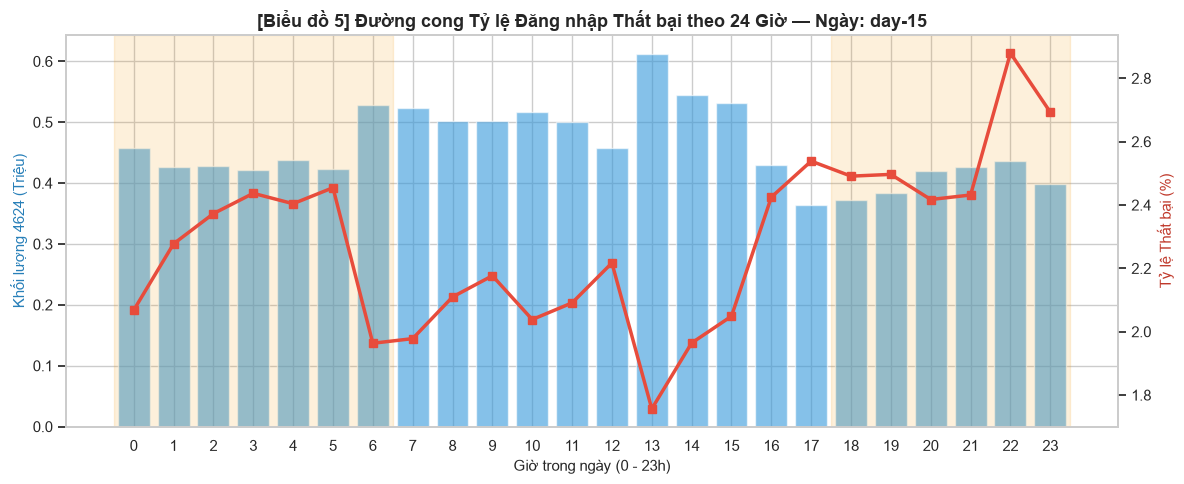

In [48]:
hours = pl.DataFrame({"Hour": range(24)})
hourly_4624 = (
    df_4624.with_columns(((pl.col("Time") // 3600) % 24).alias("Hour"))
    .group_by("Hour").agg(pl.len().alias("count_4624"))
)
hourly_4625 = (
    df_4625.with_columns(((pl.col("Time") // 3600) % 24).alias("Hour"))
    .group_by("Hour").agg(pl.len().alias("count_4625"))
)
hourly_calc = (
    hours.join(hourly_4624, on="Hour", how="left")
    .join(hourly_4625, on="Hour", how="left")
    .fill_null(0)
    .with_columns([
        ((pl.col("count_4625") / (pl.col("count_4624") + pl.col("count_4625"))) * 100).alias("fail_rate_pct")
    ])
    .sort("Hour")
    .to_pandas()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(hourly_calc["Hour"], hourly_calc["count_4624"] / 1e6, color="#3498db", alpha=0.6, label="4624 Thành công (Triệu)")
ax1.set_xlabel("Giờ trong ngày (0 - 23h)", fontsize=11)
ax1.set_ylabel("Khối lượng 4624 (Triệu)", color="#2980b9", fontsize=11)
ax1.set_xticks(range(24))

# Đánh dấu vùng ngoài giờ hành chính
ax1.axvspan(off_hours_start - 0.5, 23.5, color="#f39c12", alpha=0.15, label="Ngoài giờ (Off-hours)")
ax1.axvspan(-0.5, off_hours_end - 0.5, color="#f39c12", alpha=0.15)

# Trục tỷ lệ thất bại (%)
ax2 = ax1.twinx()
ax2.plot(hourly_calc["Hour"], hourly_calc["fail_rate_pct"], color="#e74c3c", marker="s", linewidth=2.5, label="Tỷ lệ Thất bại (%)")
ax2.set_ylabel("Tỷ lệ Thất bại (%)", color="#c0392b", fontsize=11)
ax2.grid(False)

plt.title(f"[Biểu đồ 5] Đường cong Tỷ lệ Đăng nhập Thất bại theo 24 Giờ — Ngày: {TARGET_DAY}", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### [BIỂU ĐỒ 6] Ma trận Nhiệt (Heatmap) Lý do Thất bại theo loại Logon trong Event 4625

> Heatmap cho biết failed logon tập trung ở tổ hợp `FailureReason × LogonTypeDescription` nào. Đây là phân phối nguyên nhân, chưa phải phân loại vector tấn công.

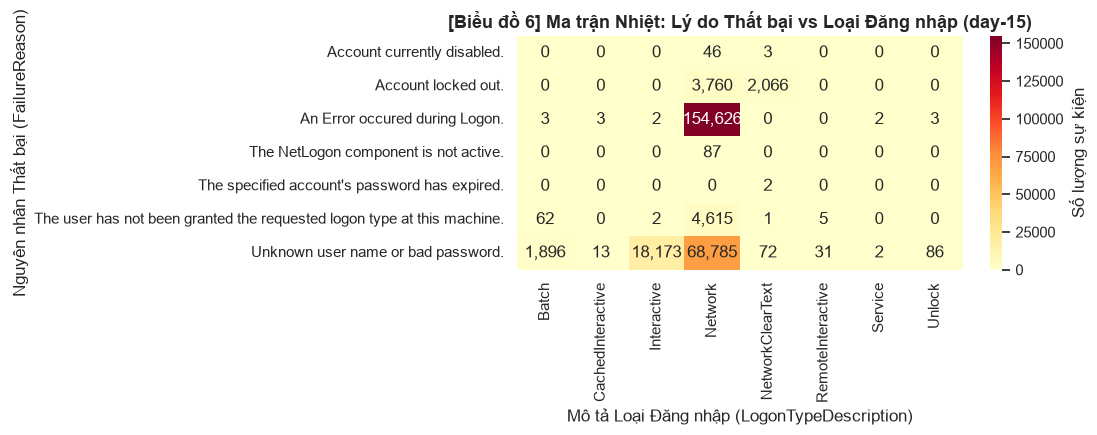

In [49]:
heatmap_matrix = (
    df_4625.group_by(["FailureReason", "LogonTypeDescription"])
    .agg(pl.len().alias("Count"))
    .to_pandas()
    .pivot(index="FailureReason", columns="LogonTypeDescription", values="Count")
    .fillna(0)
)

plt.figure(figsize=(11, 4.5))
sns.heatmap(heatmap_matrix, cmap="YlOrRd", annot=True, fmt=",.0f", cbar_kws={"label": "Số lượng sự kiện"})
plt.title(f"[Biểu đồ 6] Ma trận Nhiệt: Lý do Thất bại vs Loại Đăng nhập ({TARGET_DAY})", fontsize=13, fontweight="bold")
plt.xlabel("Mô tả Loại Đăng nhập (LogonTypeDescription)")
plt.ylabel("Nguyên nhân Thất bại (FailureReason)")
plt.tight_layout()
plt.show()

### [BIỂU ĐỒ 7] Top 10 identity có failed logon lặp nhanh

> Danh sách ưu tiên điều tra sau khi gộp các dòng giống hệt nhau. Cần xem thêm source, failure reason và baseline trước khi kết luận brute-force.

[B.2.1] Thành viên thuộc nhóm trùng: 188,930
[B.2.2] Dòng dư nếu giữ một bản: 154,089 (60.58%)
[B.2.3] Lần fail kế tiếp có Delta t <= 2s: 27,126 (27.06% sau gộp trùng)


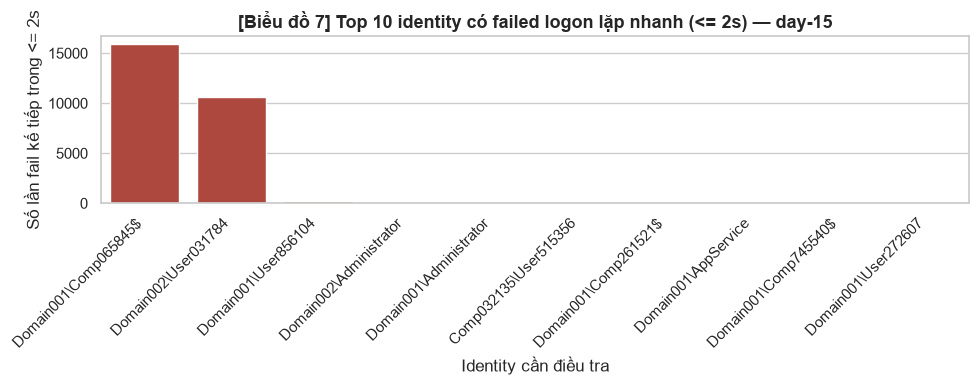

In [50]:
# 1. Duplicate quan sát được trên toàn bộ 21 cột
exact_members_4625 = int(df_4625.is_duplicated().sum())
unique_rows_4625 = df_4625.n_unique()
exact_excess_4625 = n_4625 - unique_rows_4625
exact_excess_4625_pct = exact_excess_4625 / n_4625 * 100
print(f"[B.2.1] Thành viên thuộc nhóm trùng: {exact_members_4625:,}")
print(f"[B.2.2] Dòng dư nếu giữ một bản: {exact_excess_4625:,} ({exact_excess_4625_pct:.2f}%)")

# 2. Nhịp failed logon lặp nhanh sau khi gộp dòng giống hệt nhau
df_4625_dedup = df_4625.unique(maintain_order=False)
rapid_failure_keys = ["DomainName", "UserName", "Source", "LogHost", "LogonType"]
rapid_4625 = (
    df_4625_dedup.select(["Time", *rapid_failure_keys])
    .sort([*rapid_failure_keys, "Time"])
    .with_columns([
        pl.col("Time").diff().over(rapid_failure_keys).alias("delta_t"),
        pl.col("UserName").str.ends_with("$").alias("is_machine")
    ])
)
rapid_4625_count = int((rapid_4625["delta_t"] <= 2).sum())
rapid_4625_pct = rapid_4625_count / unique_rows_4625 * 100
print(f"[B.2.3] Lần fail kế tiếp có Delta t <= 2s: {rapid_4625_count:,} ({rapid_4625_pct:.2f}% sau gộp trùng)")

# Top identity cần điều tra; giữ DomainName để tránh nhập nhầm cùng username
top_rapid_identities = (
    rapid_4625.filter(pl.col("delta_t") <= 2)
    .group_by(["DomainName", "UserName"])
    .agg(pl.len().alias("Rapid_Fail_Count"))
    .sort("Rapid_Fail_Count", descending=True)
    .limit(10)
    .with_columns(pl.concat_str([pl.col("DomainName").fill_null("<null-domain>"), pl.col("UserName")], separator="\\").alias("Identity"))
    .to_pandas()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=top_rapid_identities, x="Identity", y="Rapid_Fail_Count", color="#c0392b")
plt.title(f"[Biểu đồ 7] Top 10 identity có failed logon lặp nhanh (<= 2s) — {TARGET_DAY}", fontsize=13, fontweight="bold")
plt.xlabel("Identity cần điều tra")
plt.ylabel("Số lần fail kế tiếp trong <= 2s")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### B.5. Scorecard Chất lượng riêng cho Event 4625

In [51]:
null_reasons_4625 = df_4625["FailureReason"].null_count()
crit_nulls_4625 = sum(r["Số lượng Null"] for r in audit_4625 if r["Phân loại"] == "1. Cốt lõi Bắt buộc")
time_min_4625 = df_4625["Time"].min()
time_max_4625 = df_4625["Time"].max()
time_ok_4625 = expected_start <= time_min_4625 and time_max_4625 < expected_end
quality_gate_4625 = crit_nulls_4625 == 0 and null_reasons_4625 == 0 and time_ok_4625

scorecard_4625 = [
    {"Tiêu chí Kiểm định 4625": "1. Không có Missing Value ở trường cốt lõi", "Kết quả": f"{crit_nulls_4625} nulls", "Đánh giá": "✅ ĐẠT" if crit_nulls_4625 == 0 else "❌ KHÔNG ĐẠT"},
    {"Tiêu chí Kiểm định 4625": "2. FailureReason bắt buộc phải đầy đủ (0% null)", "Kết quả": f"{null_reasons_4625} nulls ({null_reasons_4625/n_4625*100:.2f}%)", "Đánh giá": "✅ ĐẠT" if null_reasons_4625 == 0 else "❌ KHÔNG ĐẠT"},
    {"Tiêu chí Kiểm định 4625": f"3. Time thuộc [{expected_start}, {expected_end})", "Kết quả": f"[{time_min_4625} -> {time_max_4625}]", "Đánh giá": "✅ ĐẠT" if time_ok_4625 else "❌ KHÔNG ĐẠT"},
    {"Tiêu chí Kiểm định 4625": "4. Dòng dư giống hệt nhau cần đối soát nguồn", "Kết quả": f"{exact_excess_4625_pct:.2f}% ({exact_excess_4625:,} dòng)", "Đánh giá": "⚠️ CAO — KHÔNG TỰ ĐỘNG XÓA" if exact_excess_4625_pct >= 5 else "ℹ️ THỐNG KÊ"},
    {"Tiêu chí Kiểm định 4625": "5. Lần fail kế tiếp <= 2s sau gộp trùng", "Kết quả": f"{rapid_4625_pct:.1f}% ({rapid_4625_count:,} dòng)", "Đánh giá": "ℹ️ CẦN ĐIỀU TRA, KHÔNG PHẢI NHÃN TẤN CÔNG"},
]

display(pl.DataFrame(scorecard_4625).to_pandas())
print(f"[*] QUALITY GATE 4625: {'ĐẠT' if quality_gate_4625 else 'KHÔNG ĐẠT'} — duplicate cao được giữ như một cảnh báo riêng.")

,Tiêu chí Kiểm định 4625,Kết quả,Đánh giá
0,1. Không có Missing Value ở trường cốt lõi,0 nulls,✅ ĐẠT
1,2. FailureReason bắt buộc phải đầy đủ (0% null),0 nulls (0.00%),✅ ĐẠT
2,"3. Time thuộc [1209600, 1296000)",[1209600 -> 1295999],✅ ĐẠT
3,4. Dòng dư giống hệt nhau cần đối soát nguồn,"60.58% (154,089 dòng)",⚠️ CAO — KHÔNG TỰ ĐỘNG XÓA
4,5. Lần fail kế tiếp <= 2s sau gộp trùng,"27.1% (27,126 dòng)","ℹ️ CẦN ĐIỀU TRA, KHÔNG PHẢI NHÃN TẤN CÔNG"


[*] QUALITY GATE 4625: ĐẠT — duplicate cao được giữ như một cảnh báo riêng.


---
# PHẦN C: QUALITY DASHBOARD & KHUYẾN NGHỊ

### [BIỂU ĐỒ 8] Quality Dashboard — 4 panel mô tả

Bốn panel dùng các đại lượng có định nghĩa tách biệt: volume thô, loại tài khoản theo hậu tố, hoạt động 4624 ngoài giờ và tỷ lệ dòng dư giống hệt nhau.

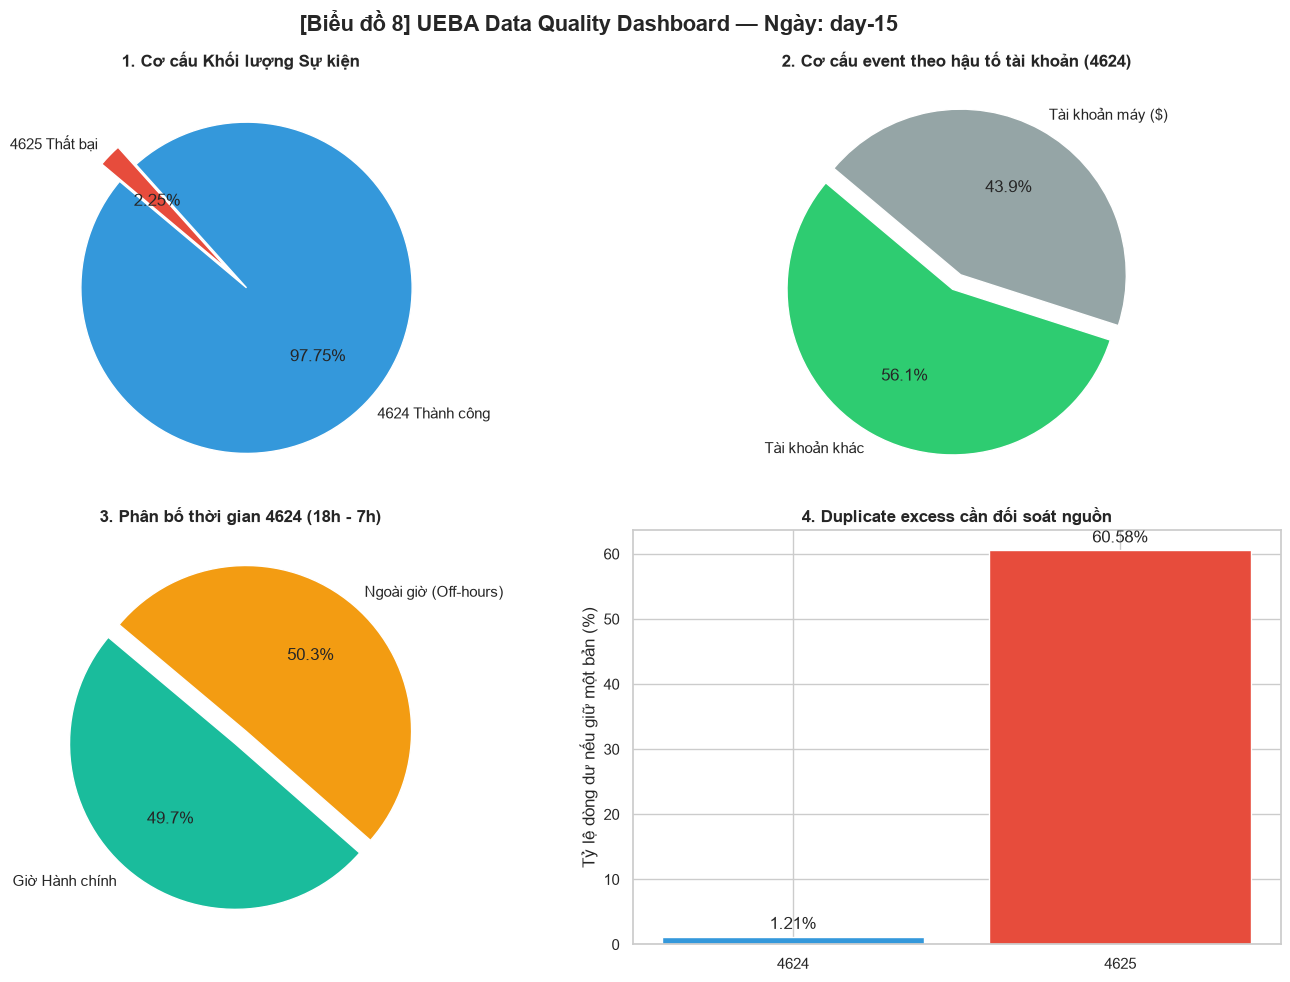

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"[Biểu đồ 8] UEBA Data Quality Dashboard — Ngày: {TARGET_DAY}", fontsize=16, fontweight="bold", y=0.98)

# Panel 1: Cơ cấu Khối lượng (4624 vs 4625)
ax1 = axes[0, 0]
ax1.pie([n_4624, n_4625], labels=["4624 Thành công", "4625 Thất bại"], autopct="%1.2f%%", colors=["#3498db", "#e74c3c"], startangle=140, explode=[0.05, 0.1])
ax1.set_title("1. Cơ cấu Khối lượng Sự kiện", fontweight="bold")

# Panel 2: Cơ cấu event theo hậu tố tài khoản trong 4624
ax2 = axes[0, 1]
n_mach = df_4624.filter(pl.col("UserName").str.ends_with("$")).height
n_user = n_4624 - n_mach
ax2.pie([n_user, n_mach], labels=["Tài khoản khác", "Tài khoản máy ($)"], autopct="%1.1f%%", colors=["#2ecc71", "#95a5a6"], startangle=140, explode=[0.05, 0.05])
ax2.set_title("2. Cơ cấu event theo hậu tố tài khoản (4624)", fontweight="bold")

# Panel 3: Phân bố Thời gian (Hành chính vs Ngoài giờ)
ax3 = axes[1, 0]
hours_all = (df_4624["Time"] // 3600) % 24
n_off = ((hours_all >= off_hours_start) | (hours_all < off_hours_end)).sum()
n_work = n_4624 - n_off
ax3.pie([n_work, n_off], labels=["Giờ Hành chính", "Ngoài giờ (Off-hours)"], autopct="%1.1f%%", colors=["#1abc9c", "#f39c12"], startangle=140, explode=[0.05, 0.05])
ax3.set_title(f"3. Phân bố thời gian 4624 ({off_hours_start}h - {off_hours_end}h)", fontweight="bold")

# Panel 4: Tỷ lệ dòng dư giống hệt nhau; hai event được tính độc lập
ax4 = axes[1, 1]
duplicate_excess_pct = [exact_excess_4624_pct, exact_excess_4625_pct]
bars = ax4.bar(["4624", "4625"], duplicate_excess_pct, color=["#3498db", "#e74c3c"])
ax4.bar_label(bars, labels=[f"{value:.2f}%" for value in duplicate_excess_pct], padding=3)
ax4.set_ylabel("Tỷ lệ dòng dư nếu giữ một bản (%)")
ax4.set_title("4. Duplicate excess cần đối soát nguồn", fontweight="bold")

plt.tight_layout()
plt.show()

### Khuyến nghị cho feature engineering ma trận Identity $\times$ Day

In [53]:
summary_comparison = pl.DataFrame({
    "Chỉ số So sánh": [
        "Tổng số lượng sự kiện",
        "Tỷ lệ trên toàn bộ Log (%)",
        "Số identity (Domain + User) duy nhất",
        "Số Host duy nhất",
        "Tỷ lệ dòng dư giống hệt nhau (%)",
        "Tỷ lệ lặp nhanh sau gộp trùng (<= 2s)",
        "Cách sử dụng tỷ lệ lặp nhanh"
    ],
    "Event 4624 (Thành công)": [
        f"{n_4624:,}",
        f"{n_4624/total_events*100:.2f}%",
        f"{df_4624.select(['DomainName', 'UserName']).n_unique():,}",
        f"{df_4624['LogHost'].n_unique():,}",
        f"{exact_excess_4624_pct:.2f}%",
        f"{rapid_4624_pct:.1f}%",
        "Feature mô tả nhịp event; không tự động sessionize"
    ],
    "Event 4625 (Thất bại)": [
        f"{n_4625:,}",
        f"{n_4625/total_events*100:.2f}%",
        f"{df_4625.select(['DomainName', 'UserName']).n_unique():,}",
        f"{df_4625['LogHost'].n_unique():,}",
        f"{exact_excess_4625_pct:.2f}%",
        f"{rapid_4625_pct:.1f}%",
        "Feature điều tra; phải kết hợp source/reason/baseline"
    ]
})

display(summary_comparison.to_pandas())

print("\n" + "="*80)
print("4 NGUYÊN TẮC FEATURE ENGINEERING:")
print("="*80)
print("1. Không tự động xóa dòng giống hệt nhau: giữ raw_count và unique_observation_count, đối soát nguồn trước khi quyết định.")
print("2. Không gọi gap <= 2s là session: lưu rapid_success_count như một feature riêng; sessionization cần quy tắc và ngưỡng được kiểm chứng.")
print("3. Với 4625, kết hợp rapid_failure_count với Source, FailureReason, số target và baseline; không dùng nó làm nhãn tấn công.")
print("4. Dùng khóa DomainName + UserName và phân nhóm machine/service/human/unknown; không coi mọi tài khoản không có '$' là người dùng thật.")

,Chỉ số So sánh,Event 4624 (Thành công),Event 4625 (Thất bại)
0,Tổng số lượng sự kiện,"11,043,849","254,346"
1,Tỷ lệ trên toàn bộ Log (%),97.75%,2.25%
2,Số identity (Domain + User) duy nhất,"9,254",279
3,Số Host duy nhất,"7,137","2,258"
4,Tỷ lệ dòng dư giống hệt nhau (%),1.21%,60.58%
5,Tỷ lệ lặp nhanh sau gộp trùng (<= 2s),80.1%,27.1%
6,Cách sử dụng tỷ lệ lặp nhanh,Feature mô tả nhịp event; không tự động sessio...,Feature điều tra; phải kết hợp source/reason/b...



4 NGUYÊN TẮC FEATURE ENGINEERING:
1. Không tự động xóa dòng giống hệt nhau: giữ raw_count và unique_observation_count, đối soát nguồn trước khi quyết định.
2. Không gọi gap <= 2s là session: lưu rapid_success_count như một feature riêng; sessionization cần quy tắc và ngưỡng được kiểm chứng.
3. Với 4625, kết hợp rapid_failure_count với Source, FailureReason, số target và baseline; không dùng nó làm nhãn tấn công.
4. Dùng khóa DomainName + UserName và phân nhóm machine/service/human/unknown; không coi mọi tài khoản không có '$' là người dùng thật.
